In [ ]:
# =============================================================================
# CREDIT CARD FRAUD DETECTION - FINAL PROJECT
# =============================================================================

# ---------------------------------------------------------
# STEP 0: IMPORT LIBRARIES
# ---------------------------------------------------------
print("Step 0: Importing Libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

# Set visualization style
sns.set_style("whitegrid")
print("Libraries imported successfully.\n")


# ---------------------------------------------------------
# STEP 1: LOAD DATA (From Google Drive)
# ---------------------------------------------------------
print("Step 1: Loading Data...")
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/creditcard.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Dataset loaded. Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
except FileNotFoundError:
    print(f"ERROR: File not found at {file_path}. Please check your Drive.")

# NOTE FOR EXAM: Explain that the dataset contains 28 anonymized features (V1-V28)
# plus 'Time' and 'Amount'. The target is 'Class'.



Step 0: Importing Libraries...
Libraries imported successfully.

Step 1: Loading Data...
Mounted at /content/drive
Dataset loaded. Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Step 0: Importing Libraries...
Libraries imported successfully.

Step 1: Loading Data...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded. Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Step 2: Performing EDA...
Legitimate Transactions: 284315
Fraudulent Transactions: 492
Fraud Percentage: 0.1727%

Dataset Summary:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.6831

Text(0.5, 1.0, 'Class Distribution')

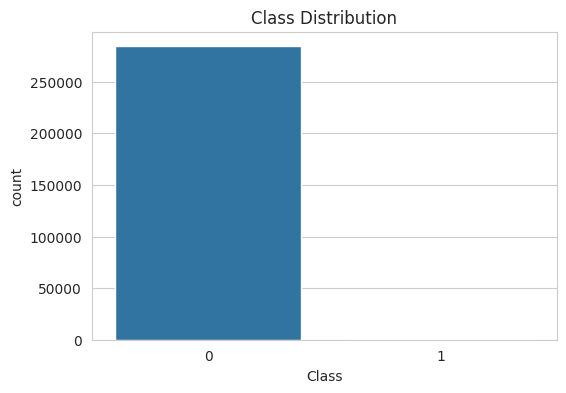

In [ ]:
# =============================================================================
# CREDIT CARD FRAUD DETECTION - FINAL PROJECT
# =============================================================================

# ---------------------------------------------------------
# STEP 0: IMPORT LIBRARIES
# ---------------------------------------------------------
print("Step 0: Importing Libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

sns.set_style("whitegrid")
print("Libraries imported successfully.\n")


# ---------------------------------------------------------
# STEP 1: LOAD DATA (From Google Drive)
# ---------------------------------------------------------
print("Step 1: Loading Data...")

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/creditcard.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Dataset loaded. Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
except Exception as e:
    raise RuntimeError(f"Failed to load dataset: {e}")

# Safety check
if 'df' not in locals():
    raise RuntimeError("Dataset 'df' is not defined. Loading failed.")


# ---------------------------------------------------------
# STEP 2: PERFORMING EDA
# ---------------------------------------------------------
print("\nStep 2: Performing EDA...")

# 2a. Check Class Imbalance
fraud_count = df['Class'].value_counts()[1]
legit_count = df['Class'].value_counts()[0]
fraud_percentage = (fraud_count / (fraud_count + legit_count)) * 100

print(f"Legitimate Transactions: {legit_count}")
print(f"Fraudulent Transactions: {fraud_count}")
print(f"Fraud Percentage: {fraud_percentage:.4f}%")

# 2b. Basic statistics
print("\nDataset Summary:")
print(df.describe())

# 2c. Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 2d. Class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")


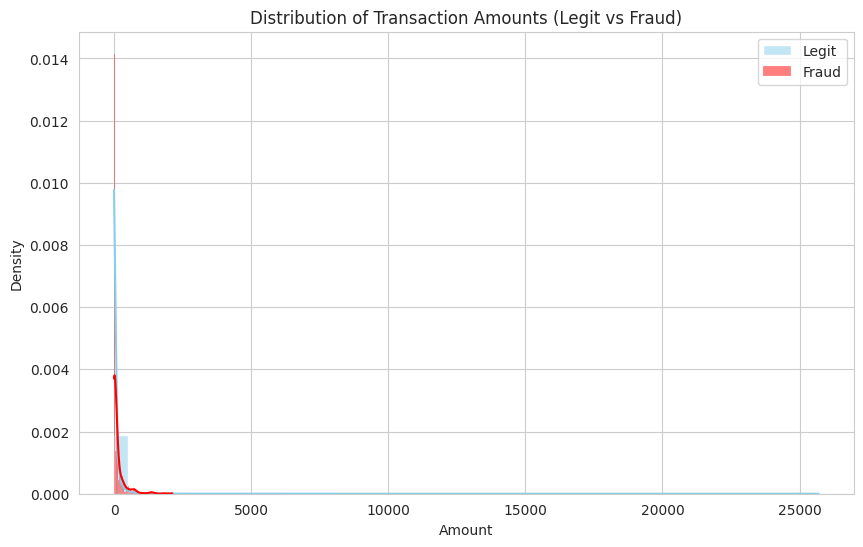

In [ ]:
# 2b. Transaction Amount Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='skyblue', label='Legit', kde=True, stat="density")
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', label='Fraud', kde=True, stat="density")
plt.title('Distribution of Transaction Amounts (Legit vs Fraud)')
plt.legend()
plt.show()

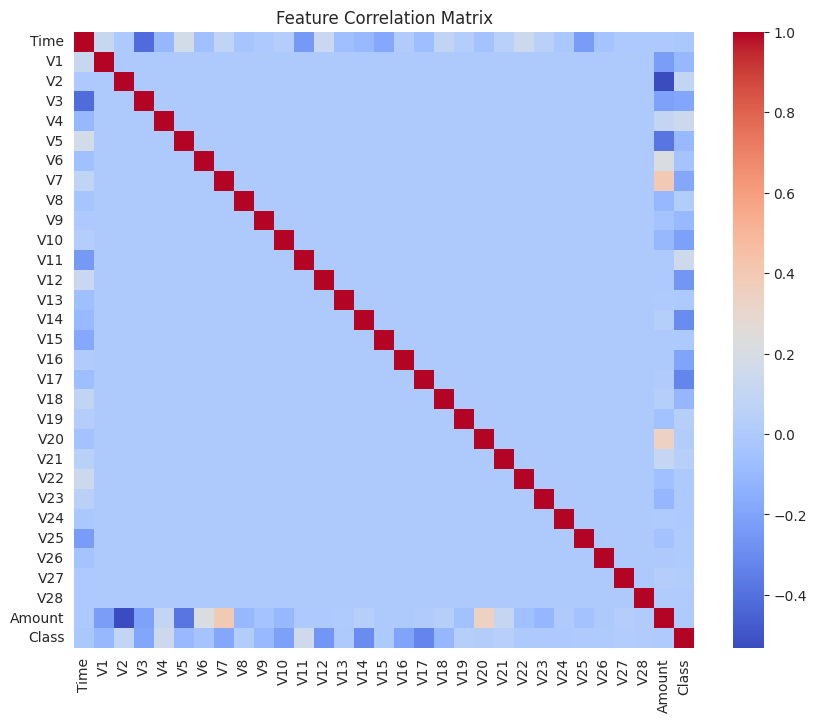

In [ ]:
# 2c. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
# ---------------------------------------------------------
# STEP 3: PREPROCESSING & SCALING
# ---------------------------------------------------------
print("\nStep 3: Preprocessing Data...")

# NOTE FOR EXAM: V1-V28 are already scaled (PCA).
# However, 'Time' and 'Amount' vary wildly, so we must scale them using StandardScaler.

scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time_Scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original columns and define X (Features) and y (Target)
X = df.drop(['Time', 'Amount', 'Class'], axis=1)
# Add scaled versions back
X['Amount'] = df['Amount_Scaled']
X['Time'] = df['Time_Scaled']
y = df['Class']

# Split Data (80% Train, 20% Test)
# Stratify=y ensures we have the same proportion of fraud in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data Split Complete.")
print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")


Step 3: Preprocessing Data...
Data Split Complete.
Training Shape: (227845, 32)
Testing Shape: (56962, 32)


In [ ]:
# ---------------------------------------------------------
# STEP 4: MODEL TRAINING (5 MODELS)
# ---------------------------------------------------------
print("\nStep 4: Training Models (This may take a moment)...")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []
roc_data = {}

for name, model in models.items():
    print(f" -> Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1})

    # Store ROC Data
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        roc_data[name] = (fpr, tpr, roc_auc)

results_df = pd.DataFrame(results)
print("\nModel Training Complete.")



Step 4: Training Models (This may take a moment)...
 -> Training Logistic Regression...
 -> Training Decision Tree...
 -> Training Random Forest...
 -> Training Gradient Boosting...
 -> Training KNN...

Model Training Complete.



Step 5: Comparing Models...
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.975475   0.060852  0.918367  0.114141
1        Decision Tree  0.999017   0.714286  0.714286  0.714286
2        Random Forest  0.999491   0.960000  0.734694  0.832370
3    Gradient Boosting  0.998315   0.529412  0.183673  0.272727
4                  KNN  0.999579   0.940476  0.806122  0.868132


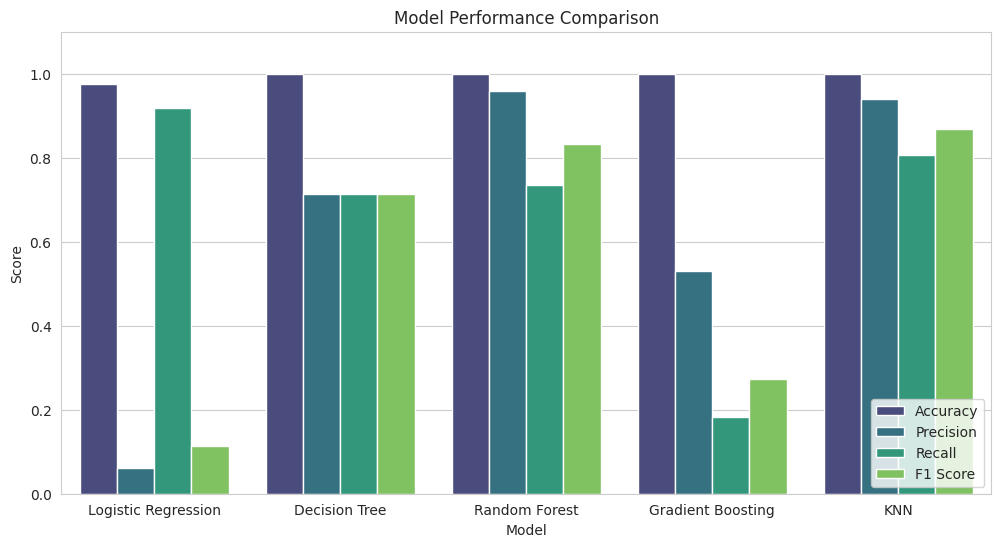

In [ ]:
# ---------------------------------------------------------
# STEP 5: EVALUATION & COMPARISON
# ---------------------------------------------------------
print("\nStep 5: Comparing Models...")
print(results_df)

# 5a. Bar Plot of Metrics
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Score", hue="Metric", data=results_melted, palette='viridis')
plt.title("Model Performance Comparison")
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.show()

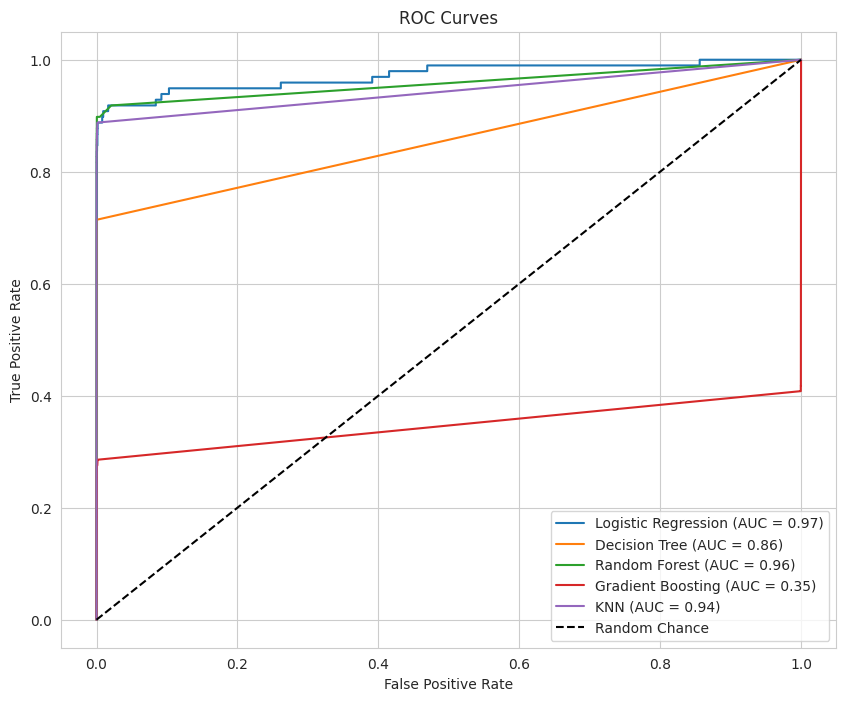

In [ ]:
# 5b. ROC Curves
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()


Step 6: Generating Advanced Diagnostics...


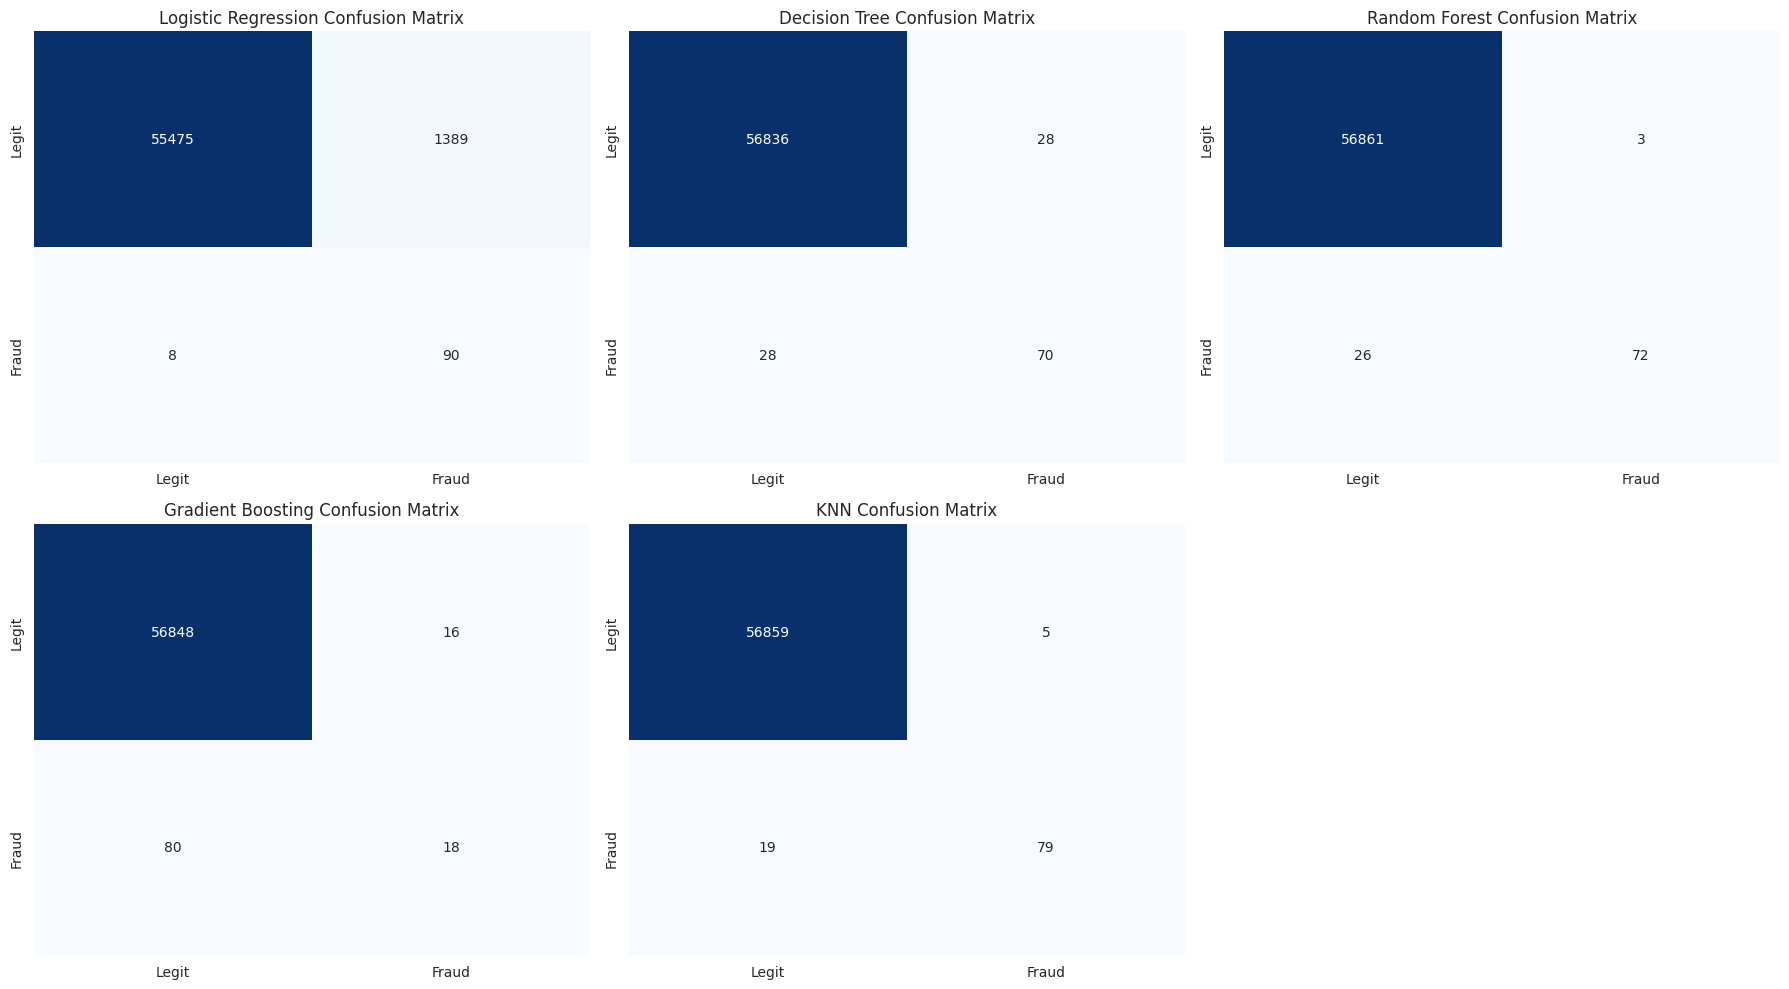

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 6: ADVANCED DIAGNOSTICS (High Marks Section)
# ---------------------------------------------------------
print("\nStep 6: Generating Advanced Diagnostics...")

# 6a. Confusion Matrix Grid
plt.figure(figsize=(18, 10))
for i, (name, model) in enumerate(models.items()):
    plt.subplot(2, 3, i+1)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    plt.title(f'{name} Confusion Matrix')
plt.tight_layout()
plt.show()

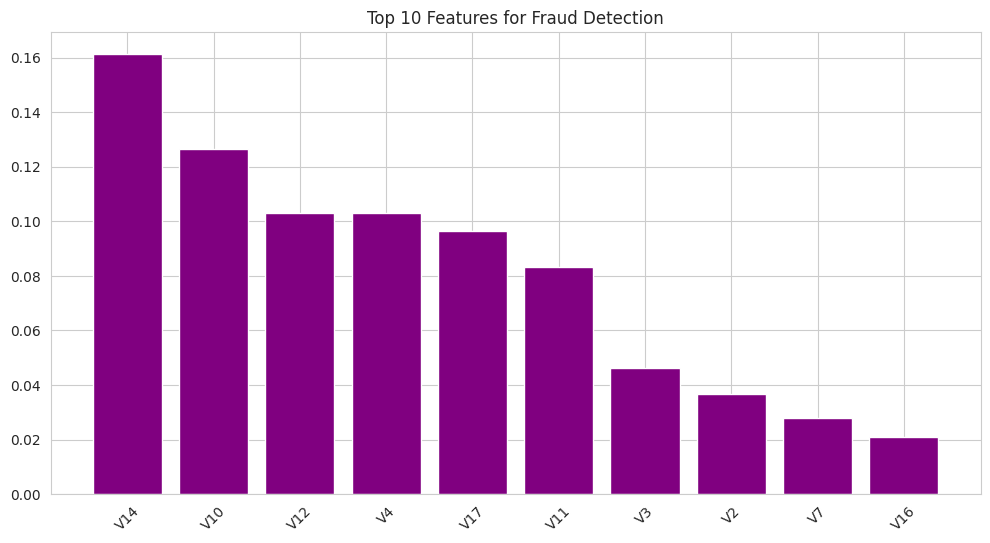

In [ ]:
# 6b. Feature Importance (Random Forest)
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title('Top 10 Features for Fraud Detection')
plt.bar(range(10), importances[indices[:10]], align='center', color='purple')
plt.xticks(range(10), [X.columns[i] for i in indices[:10]], rotation=45)
plt.show()
